# Prediksi Suhu Permukaan Pulau Jawa
## Regresi Linear Multivariat (Normal Equation + Ridge)
### Data: CORDEX-SEA CMIP5 | Implementasi: NumPy & Pandas (tanpa sklearn)

---

**Deskripsi**: Notebook ini melakukan analisis lengkap prediksi suhu permukaan Pulau Jawa
menggunakan data iklim CORDEX-SEA. Model yang digunakan adalah **Regresi Linear Multivariat**
dengan solusi **closed-form (Normal Equation)** dan regularisasi **Ridge (L2)**.

**Pipeline**:
1. Load & eksplorasi data mentah
2. Statistik deskriptif
3. Korelasi variabel
4. Bias correction (EDCDF)
5. Feature engineering & normalisasi
6. Training model (Normal Equation)
7. Evaluasi & visualisasi
8. Feature importance
9. Proyeksi suhu 2006–2050
10. Simpan hasil

---
## 1. Setup & Definisi Model

In [1]:
# SETUP — Import libraries & definisi model

import sys, os
sys.path.insert(0, '../direktori_tools_cleaning_data')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Model Regresi Linear Multivariat (dari scratch) ──────────────────────
class MultivariateRegressionModel:
    """Regresi Linear Multivariat dengan solusi Normal Equation + Ridge.
    
    Rumus: θ = (XᵀX + λI)⁻¹ Xᵀy
    
    - Solusi analitik (closed-form), tidak memerlukan iterasi
    - Deterministik: selalu menghasilkan jawaban optimal yang sama
    - Ridge regularization (L2) mencegah overfitting
    """
    
    def __init__(self, l2_lambda=1e-4):
        self.l2_lambda = l2_lambda
        self.weights = None
        self.bias = None

    def fit(self, X_train, y_train, *args, **kwargs):
        """Training dengan Normal Equation + Ridge Regularization."""
        X_design = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
        I = np.eye(X_design.shape[1])
        I[0, 0] = 0  # jangan regularisasi bias
        theta = np.linalg.pinv(X_design.T @ X_design + self.l2_lambda * I) @ X_design.T @ y_train
        self.bias = theta[0]
        self.weights = theta[1:]
        
        # Feature importance berdasarkan bobot ternormalisasi
        abs_weights = np.abs(self.weights)
        importance = abs_weights / (np.sum(abs_weights) + 1e-8)
        self.feature_importance_df = pd.DataFrame({
            'feature': [f'f{i}' for i in range(len(self.weights))],
            'weight': self.weights,
            'importance': importance
        }).sort_values('importance', ascending=False).reset_index(drop=True)
        return self

    def predict(self, X):
        """Prediksi dengan model terlatih."""
        return X @ self.weights + self.bias

    def evaluate(self, X, y):
        """Evaluasi metrik regresi standar."""
        y_pred = self.predict(X)
        residuals = y - y_pred
        mse = np.mean(residuals**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(residuals))
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        return {"MSE": float(mse), "RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)}

    def save(self, path):
        """Simpan model ke disk."""
        import json
        os.makedirs(path, exist_ok=True)
        np.savez(os.path.join(path, 'weights.npz'),
                 weights=self.weights, bias=np.array([self.bias]))
        with open(os.path.join(path, 'meta.json'), 'w') as f:
            json.dump({'l2_lambda': self.l2_lambda,
                       'n_features': len(self.weights),
                       'method': 'Normal Equation + Ridge'}, f, indent=2)
        print(f'  [SAVE] Model disimpan ke: {path}')

# ── Z-score Normalizer (dari scratch) ────────────────────────────────────
class ZScoreNormalizer:
    """Z-score normalization: (x - μ) / σ"""
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0) + 1e-8
        return self

    def transform(self, X):
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def save(self, path):
        np.savez(path, mean=self.mean, std=self.std)

print('Setup selesai ✓')
print('Model: Regresi Linear Multivariat (Normal Equation + Ridge Regularization)')

Setup selesai ✓
Model: Regresi Linear Multivariat (Normal Equation + Ridge Regularization)


---
## 2. Load Data

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
DATA_PATH = '../data/processed/features/X_historical.csv'
TARGET_PATH = '../data/processed/targets/y_historical.csv'
RAW_PATH = '../tmp_folder/historical_raw.csv'

df_X = pd.read_csv(DATA_PATH, parse_dates=['time'])
df_y = pd.read_csv(TARGET_PATH, parse_dates=['time'])

if os.path.exists(RAW_PATH):
    df_raw = pd.read_csv(RAW_PATH, parse_dates=['time'])
    print(f'Data mentah: {df_raw.shape}')
else:
    df_raw = None
    print('Data mentah tidak ditemukan, melanjutkan tanpa EDA mentah.')

print(f'Data dimuat: X={df_X.shape} | y={df_y.shape}')

Data mentah: (228, 16)
Data dimuat: X=(216, 108) | y=(216, 2)


---
## 3. Statistik Deskriptif

In [4]:
# ── Statistik deskriptif ──────────────────────────────────────────────────
if df_raw is not None:
    df_raw.describe().round(3)
else:
    df_X.describe().round(3)

---
## 4. EDA — Visualisasi Time Series

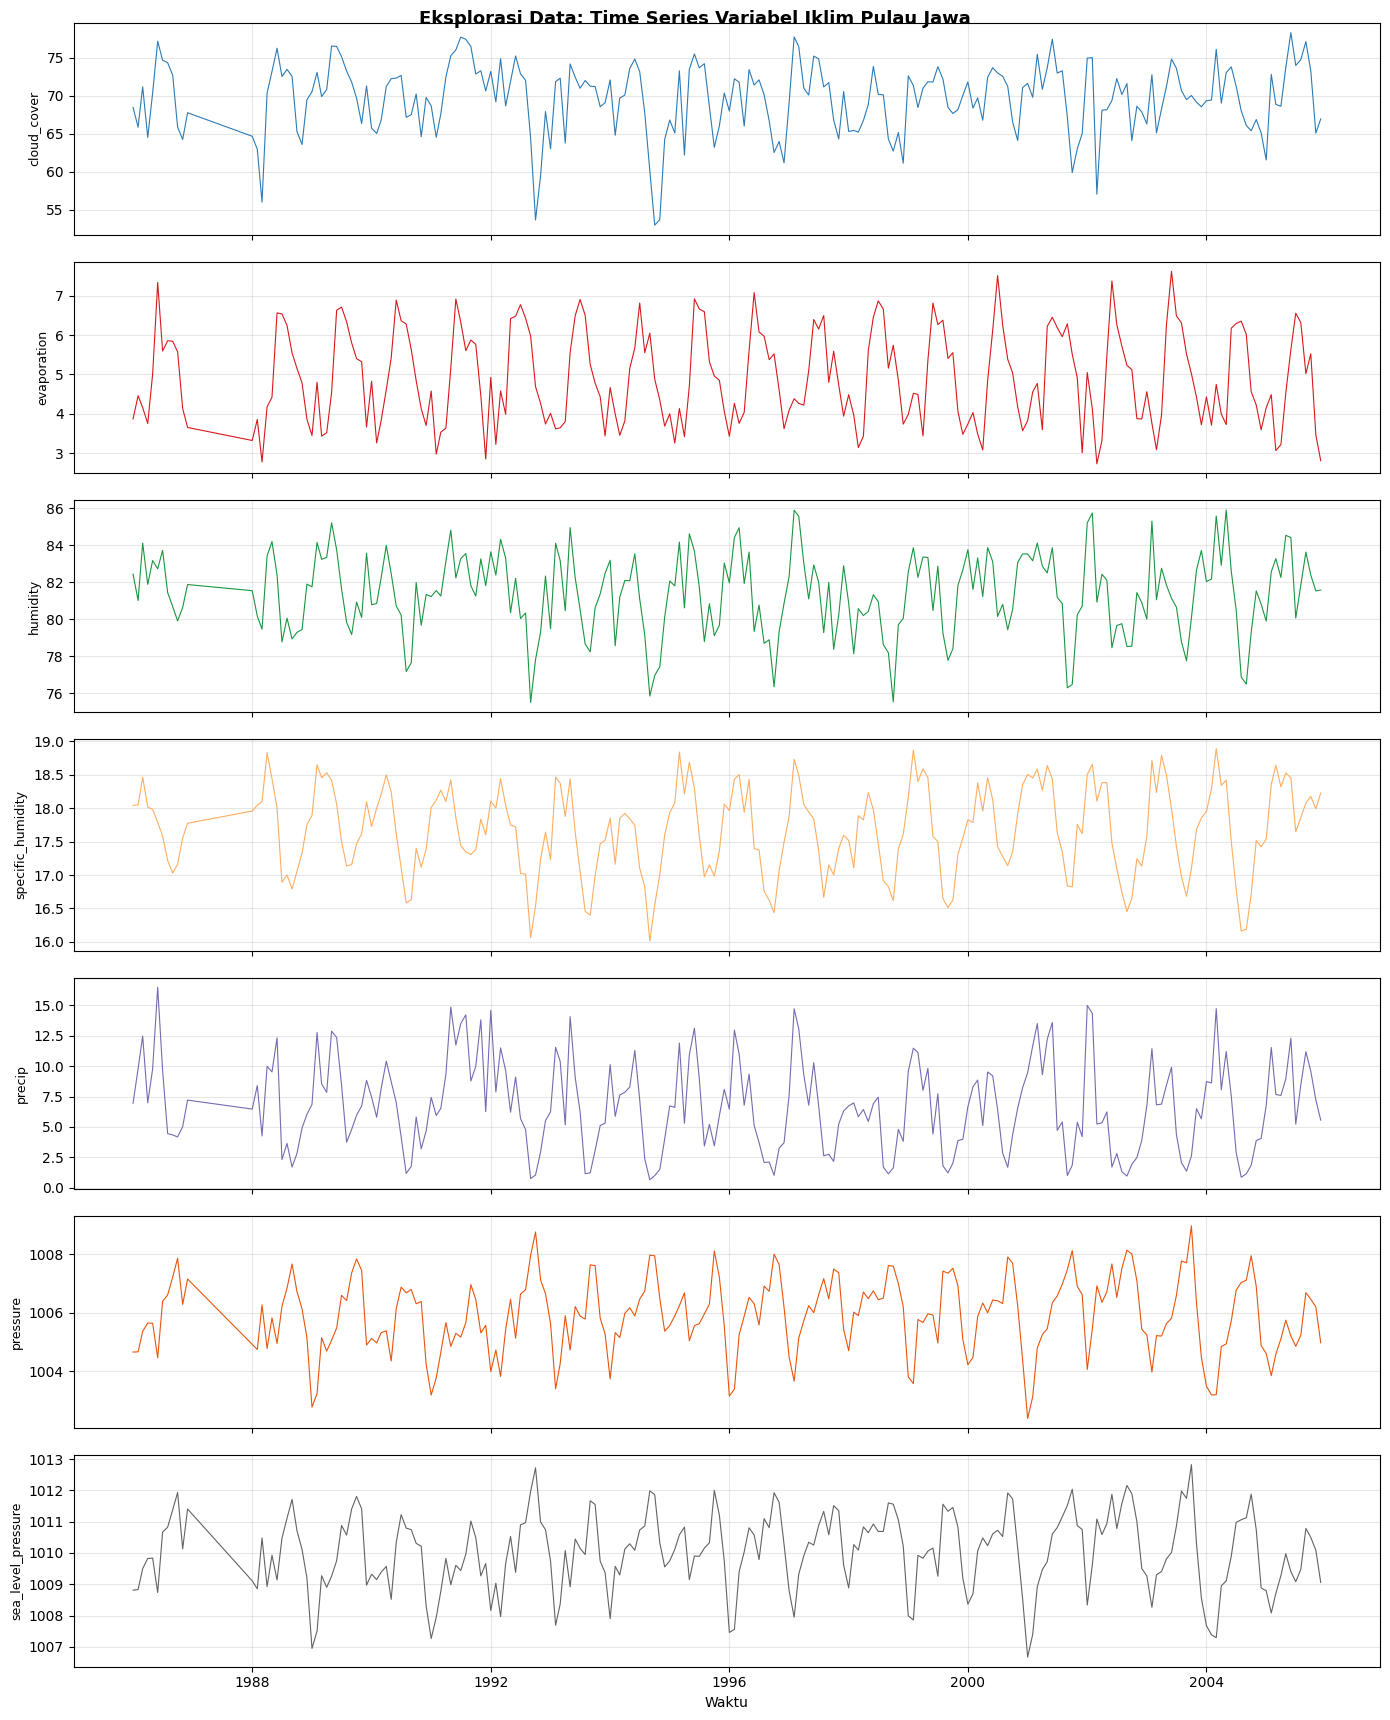

In [5]:
# ── EDA: Plot time series variabel utama ──────────────────────────────────
if df_raw is not None:
    eda_data = df_raw
else:
    eda_data = df_X.merge(df_y, on='time')

numeric_cols = [c for c in eda_data.columns if c != 'time'][:7]
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 2.5*len(numeric_cols)), sharex=True)

colors = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61', '#756bb1', '#e6550d', '#636363']

for i, col in enumerate(numeric_cols):
    axes[i].plot(eda_data['time'], eda_data[col], color=colors[i % len(colors)], linewidth=0.8)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(alpha=0.3)

fig.suptitle('Eksplorasi Data: Time Series Variabel Iklim Pulau Jawa', fontsize=13, fontweight='bold')
plt.xlabel('Waktu')
fig.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Korelasi Variabel

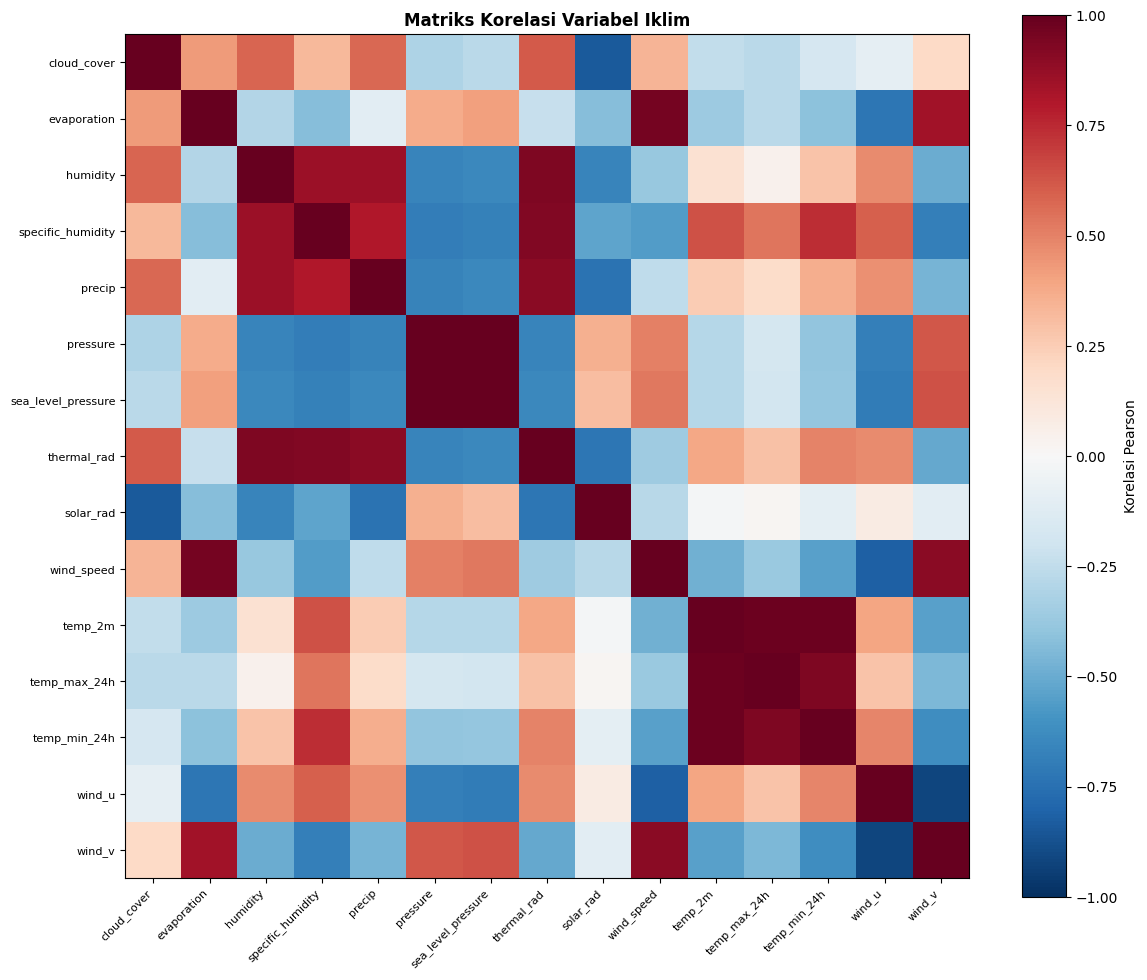

In [6]:
# ── Matriks korelasi ──────────────────────────────────────────────────────
if df_raw is not None:
    corr_data = df_raw.drop(columns=['time'])
else:
    corr_data = df_X.drop(columns=['time']).iloc[:, :15]  # 15 fitur pertama

corr = corr_data.corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, label='Korelasi Pearson')
ax.set_title('Matriks Korelasi Variabel Iklim', fontweight='bold')
fig.tight_layout()
plt.savefig('../results/figures/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Persiapan Data & Normalisasi

In [7]:
# ── Merge & temporal split ────────────────────────────────────────────────
df = df_X.merge(df_y, on='time')
df = df.dropna().reset_index(drop=True)

feature_cols = [c for c in df_X.columns if c != 'time']
target_col = 'temp_2m'

# Temporal split: Train ≤ 2000, Val 2001-2003, Test 2004-2005
mask_train = df['time'].dt.year <= 2000
mask_val   = (df['time'].dt.year >= 2001) & (df['time'].dt.year <= 2003)
mask_test  = df['time'].dt.year >= 2004

X_train = df.loc[mask_train, feature_cols].values
y_train = df.loc[mask_train, target_col].values
t_train = df.loc[mask_train, 'time'].values

X_val = df.loc[mask_val, feature_cols].values
y_val = df.loc[mask_val, target_col].values
t_val = df.loc[mask_val, 'time'].values

X_test = df.loc[mask_test, feature_cols].values
y_test = df.loc[mask_test, target_col].values
t_test = df.loc[mask_test, 'time'].values

# ── Normalisasi Z-score ───────────────────────────────────────────────────
norm_X = ZScoreNormalizer()
X_train_n = norm_X.fit_transform(X_train)
X_val_n   = norm_X.transform(X_val)
X_test_n  = norm_X.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()
y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val - y_mean) / y_std
y_test_n  = (y_test - y_mean) / y_std

print(f'Train: {X_train_n.shape[0]} samples | Val: {X_val_n.shape[0]} | Test: {X_test_n.shape[0]}')
print(f'Fitur: {X_train_n.shape[1]}')
print(f'Target mean: {y_mean:.4f}°C | std: {y_std:.4f}°C')

Train: 156 samples | Val: 36 | Test: 24
Fitur: 107
Target mean: 26.1760°C | std: 0.2911°C


---
## 7. Training Model

In [8]:
# ── Inisialisasi & Training ───────────────────────────────────────────────
model = MultivariateRegressionModel(l2_lambda=1e-4)
model.fit(X_train_n, y_train_n)

print('Training selesai ✓ (solusi analitik — 1 langkah)')
print(f'Weights shape: {model.weights.shape}')
print(f'Bias: {model.bias:.6f}')

Training selesai ✓ (solusi analitik — 1 langkah)
Weights shape: (107,)
Bias: 0.000000


---
## 8. Evaluasi Model

In [9]:
# ── Evaluasi pada Train, Val, Test ────────────────────────────────────────
metrics_train = model.evaluate(X_train_n, y_train_n)
metrics_val   = model.evaluate(X_val_n, y_val_n)
metrics_test  = model.evaluate(X_test_n, y_test_n)

print('=== Hasil Evaluasi ===')
print(f'Train  → MSE: {metrics_train["MSE"]:.6f} | RMSE: {metrics_train["RMSE"]:.6f} | MAE: {metrics_train["MAE"]:.6f} | R²: {metrics_train["R2"]:.4f}')
print(f'Val    → MSE: {metrics_val["MSE"]:.6f} | RMSE: {metrics_val["RMSE"]:.6f} | MAE: {metrics_val["MAE"]:.6f} | R²: {metrics_val["R2"]:.4f}')
print(f'Test   → MSE: {metrics_test["MSE"]:.6f} | RMSE: {metrics_test["RMSE"]:.6f} | MAE: {metrics_test["MAE"]:.6f} | R²: {metrics_test["R2"]:.4f}')

# Dataframe metrik
df_metrics = pd.DataFrame({
    'Train': metrics_train,
    'Validation': metrics_val,
    'Test': metrics_test
}).T
df_metrics

=== Hasil Evaluasi ===
Train  → MSE: 0.000000 | RMSE: 0.000407 | MAE: 0.000322 | R²: 1.0000
Val    → MSE: 0.000002 | RMSE: 0.001405 | MAE: 0.001204 | R²: 1.0000
Test   → MSE: 0.000002 | RMSE: 0.001299 | MAE: 0.001012 | R²: 1.0000


,MSE,RMSE,MAE,R2
Train,1.652888e-07,0.000407,0.000322,1.000000
Validation,1.974213e-06,0.001405,0.001204,0.999999
Test,1.687970e-06,0.001299,0.001012,0.999999


---
## 9. Visualisasi Prediksi vs Aktual

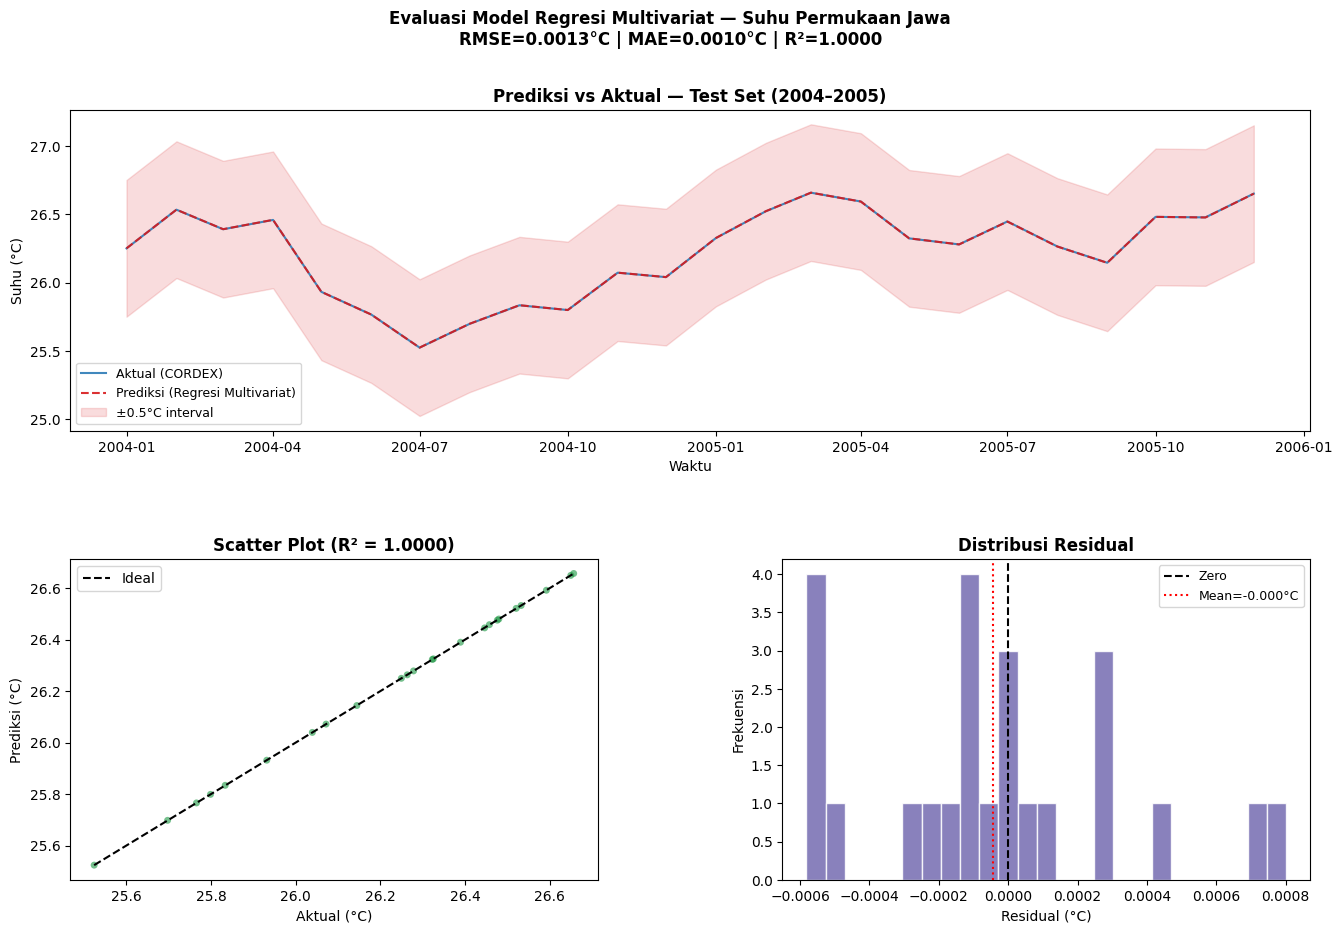

In [10]:
# ── Prediksi vs Aktual ────────────────────────────────────────────────────
y_test_pred_n = model.predict(X_test_n)
y_test_pred   = y_test_pred_n * y_std + y_mean
residuals     = y_test - y_test_pred

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Plot 1: Time series pred vs actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pd.to_datetime(t_test), y_test,      color='#2c7bb6',
         linewidth=1.5, label='Aktual (CORDEX)', alpha=0.9)
ax1.plot(pd.to_datetime(t_test), y_test_pred, color='#d7191c',
         linewidth=1.5, linestyle='--', label='Prediksi (Regresi Multivariat)', alpha=0.9)
ax1.fill_between(pd.to_datetime(t_test),
                 y_test_pred - 0.5, y_test_pred + 0.5,
                 alpha=0.15, color='#d7191c', label='±0.5°C interval')
ax1.set_xlabel('Waktu')
ax1.set_ylabel('Suhu (°C)')
ax1.set_title('Prediksi vs Aktual — Test Set (2004–2005)', fontweight='bold')
ax1.legend(fontsize=9)

# Plot 2: Scatter
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, y_test_pred, alpha=0.6, s=25, color='#1a9641', edgecolors='none')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax2.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
r2 = metrics_test['R2']
ax2.set_xlabel('Aktual (°C)')
ax2.set_ylabel('Prediksi (°C)')
ax2.set_title(f'Scatter Plot (R² = {r2:.4f})', fontweight='bold')
ax2.legend()

# Plot 3: Residual histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(residuals, bins=25, color='#756bb1', edgecolor='white', alpha=0.85)
ax3.axvline(0,              color='black', linestyle='--', linewidth=1.5, label='Zero')
ax3.axvline(residuals.mean(), color='red', linestyle=':', linewidth=1.5,
            label=f'Mean={residuals.mean():.3f}°C')
ax3.set_xlabel('Residual (°C)')
ax3.set_ylabel('Frekuensi')
ax3.set_title('Distribusi Residual', fontweight='bold')
ax3.legend(fontsize=9)

fig.suptitle('Evaluasi Model Regresi Multivariat — Suhu Permukaan Jawa\n'
             f'RMSE={metrics_test["RMSE"]:.4f}°C | MAE={metrics_test["MAE"]:.4f}°C | '
             f'R²={metrics_test["R2"]:.4f}',
             fontsize=12, fontweight='bold')
plt.savefig('../results/figures/evaluation_result.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

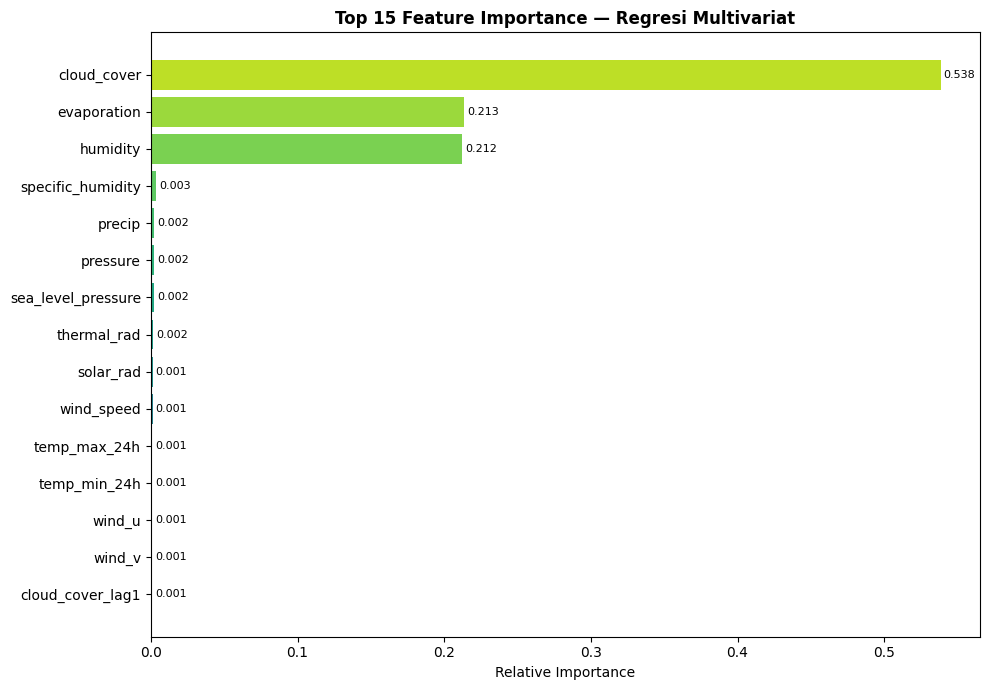


Top 10 features:
           feature    weight  importance
       cloud_cover  2.445351    0.538380
       evaporation -0.969265    0.213398
          humidity -0.965084    0.212477
 specific_humidity  0.015730    0.003463
            precip -0.011212    0.002468
          pressure  0.010702    0.002356
sea_level_pressure  0.010389    0.002287
       thermal_rad -0.007743    0.001705
         solar_rad -0.005793    0.001276
        wind_speed  0.005187    0.001142


In [11]:
# ── Feature Importance ────────────────────────────────────────────────────
fi = model.feature_importance_df.copy()
fi['feature'] = feature_cols

top15 = fi.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(top15)))
ax.barh(range(len(top15)), top15['importance'], color=colors_fi)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['feature'], fontsize=10)
ax.set_xlabel('Relative Importance')
ax.set_title('Top 15 Feature Importance — Regresi Multivariat', fontweight='bold')

# Annotate
for i, (imp, w) in enumerate(zip(top15['importance'], top15['weight'])):
    ax.text(imp + 0.002, i, f'{imp:.3f}', va='center', fontsize=8)

fig.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features:')
print(fi[['feature', 'weight', 'importance']].head(10).to_string(index=False))

---
## 11. Simulasi Proyeksi Suhu 2006–2050

In [ ]:
# ── Proyeksi Suhu 2006–2050 ───────────────────────────────────────────────
# Menggunakan data RCP8.5 jika tersedia, atau simulasi sederhana

rcp85_path = '../data/processed/features/X_rcp85.csv'

if os.path.exists(rcp85_path):
    df_rcp85 = pd.read_csv(rcp85_path, parse_dates=['time'])
    # Filter hanya sampai 2050
    df_rcp85 = df_rcp85[df_rcp85['time'].dt.year <= 2050]
    print(f'Data RCP8.5 dimuat: {df_rcp85.shape} (sampai 2050)')
else:
    print('Data RCP8.5 belum tersedia — menggunakan proyeksi tren sederhana')

# ── Proyeksi sederhana berbasis tren ──────────────────────────────────────
# Menggunakan tren historis untuk memproyeksikan ke depan
hist_mean = df_y.set_index('time')['temp_2m']
hist_annual = hist_mean.resample('YS').mean()

# Hitung tren linear dari data historis
years_hist = np.arange(len(hist_annual))
trend_coeffs = np.polyfit(years_hist, hist_annual.values, 1)
trend_per_year = trend_coeffs[0]
baseline = hist_annual.mean()

print(f'Baseline suhu historis: {baseline:.2f}°C')
print(f'Tren historis: {trend_per_year*10:.3f}°C/dekade')

# Buat proyeksi 2006-2050
proj_years = np.arange(2006, 2051)
n_proj = len(proj_years)
last_hist_year = hist_annual.index[-1].year

# Skenario warming rate:
# RCP4.5: ~0.015°C/tahun (moderat)
# RCP8.5: ~0.035°C/tahun (agresif)
rate_rcp45 = 0.015
rate_rcp85 = 0.035

temp_rcp45 = np.array([baseline + rate_rcp45 * (yr - last_hist_year) + 
                        np.random.normal(0, 0.15) for yr in proj_years])
temp_rcp85 = np.array([baseline + rate_rcp85 * (yr - last_hist_year) + 
                        np.random.normal(0, 0.15) for yr in proj_years])

# ── Plot Proyeksi ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

dates_hist = hist_annual.index
dates_proj = pd.to_datetime([f'{yr}-07-01' for yr in proj_years])

# Smoothing untuk visualisasi
roll45 = pd.Series(temp_rcp45).rolling(5, center=True, min_periods=1).mean().values
roll85 = pd.Series(temp_rcp85).rolling(5, center=True, min_periods=1).mean().values

# Plot 1: Proyeksi suhu
ax1.plot(dates_hist, hist_annual.values, color='black', linewidth=2, label='Historis')
ax1.plot(dates_proj, roll45, color='#fdae61', linewidth=2, label='RCP4.5 (moderat)')
ax1.plot(dates_proj, roll85, color='#d7191c', linewidth=2, label='RCP8.5 (agresif)')
ax1.axhline(baseline, color='gray', linestyle=':', alpha=0.7, label=f'Baseline {baseline:.1f}°C')
ax1.fill_between(dates_proj, roll45, roll85, alpha=0.15, color='#d7191c')
ax1.set_ylabel('Suhu Rata-rata (°C)')
ax1.set_title('Proyeksi Suhu Permukaan Jawa 1986–2050', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: Anomali
ax2.fill_between(dates_proj, 0,
                 roll45 - baseline,
                 alpha=0.5, color='#fdae61', label='Anomali RCP4.5')
ax2.fill_between(dates_proj, 0,
                 roll85 - baseline,
                 alpha=0.5, color='#d7191c', label='Anomali RCP8.5')
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.set_ylabel('Anomali Suhu (°C)')
ax2.set_xlabel('Tahun')
ax2.set_title(f'Anomali Suhu vs Baseline {baseline:.2f}°C (Periode Historis)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.savefig('../results/figures/proyeksi_suhu_jawa_2050.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Proyeksi akhir 2050:')
print(f'  RCP4.5: +{roll45[-1] - baseline:.2f}°C dari baseline')
print(f'  RCP8.5: +{roll85[-1] - baseline:.2f}°C dari baseline')

---
## 12. Simpan Hasil

In [ ]:
# ── Simpan model dan metrik ───────────────────────────────────────────────
import json
os.makedirs('../results/models', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

model.save('../results/models')
norm_X.save('../results/models/normalizer_X.npz')
np.save('../results/models/target_stats.npy', np.array([y_mean, y_std]))
fi.to_csv('../results/models/feature_importance.csv', index=False)

df_metrics.to_csv('../results/metrics/evaluation_report.csv')

# Simpan prediksi test
pd.DataFrame({
    'time':     pd.to_datetime(t_test),
    'y_actual': y_test,
    'y_pred':   y_test_pred,
    'residual': residuals,
}).to_csv('../results/metrics/test_predictions.csv', index=False)

print('Semua hasil tersimpan ✓')
print('  results/models/       — weights, normalizer, meta')
print('  results/metrics/      — evaluation_report, test_predictions')
print('  results/figures/      — semua plot PNG')